Venkatesh Godi-BMB2058

In [ ]:
import tensorflow as tf
mnist=tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print("Train image shape",train_images.shape)
print("Train label shape",train_labels.shape)
print("Test image shape",test_images.shape)
print("Test label shape",test_labels.shape)

Train image shape (60000, 28, 28)
Train label shape (60000,)
Test image shape (10000, 28, 28)
Test label shape (10000,)


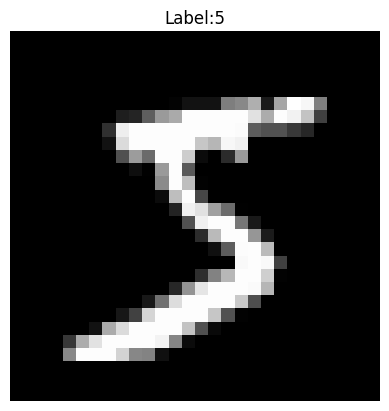

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_images[0],cmap='gray')
plt.title(f"Label:{train_labels[0]}")
plt.axis('off')
plt.show()

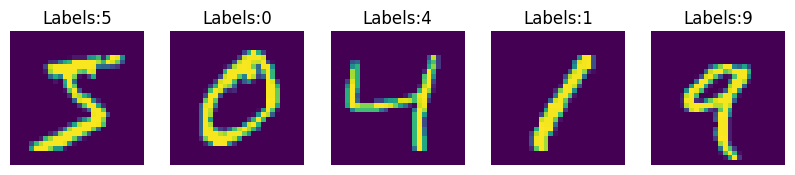

In [ ]:
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(train_images[i])
  plt.title(f"Labels:{train_labels[i]}")
  plt.axis("off")
plt.show()

In [ ]:
train_images=train_images/255
test_images=test_images/255

In [ ]:
train_images=train_images.reshape(60000,28,28,1)
test_images=test_images.reshape(10000,28,28,1)

In [ ]:
from tensorflow.keras import layers, models
model=models.Sequential([
    layers.Conv2D(16,(3,3),activation="relu",input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(32,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images,train_labels,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9385 - loss: 0.2178
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9762 - loss: 0.0782
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9832 - loss: 0.0556


In [ ]:
test_loss,test_acc=model.evaluate(test_images,test_labels)
print("Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9801 - loss: 0.0594
Accuracy: 0.9800999760627747


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Original Label: 6
Predicted Label: 6


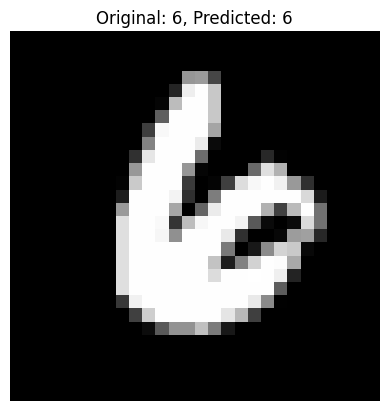

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
# Step 4: Build CNN model
import tensorflow as tf
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, train_labels
, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Accuracy:", test_acc)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9419 - loss: 0.1921
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9804 - loss: 0.0623
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9853 - loss: 0.0456
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9853 - loss: 0.0462
Accuracy: 0.9853000044822693
